In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models

In [74]:
dataset_path = "/content/drive/MyDrive/dataset"

In [75]:
img_height = 224
img_width = 224
batch_size = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 149 files belonging to 4 classes.
Using 105 files for training.
Found 149 files belonging to 4 classes.
Using 44 files for validation.


In [76]:
class_names = train_ds.class_names
print(class_names)

['gelo', 'rocha', 'solo_arenoso', 'solo_escuro']


In [77]:
val_batches = tf.data.experimental.cardinality(temp_ds)

val_ds = temp_ds.take(val_batches // 2)
test_ds = temp_ds.skip(val_batches // 2)

In [78]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [79]:
normalization_layer = layers.Rescaling(1./255)

In [80]:
model1 = models.Sequential([

    data_augmentation,
    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(4, activation='softmax')
])

In [81]:
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [82]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

In [83]:
history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop]
)

Epoch 1/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.3810 - loss: 1.8666 - val_accuracy: 0.4167 - val_loss: 1.3804
Epoch 2/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7048 - loss: 0.7883 - val_accuracy: 0.2500 - val_loss: 2.8816
Epoch 3/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.6571 - loss: 1.0033 - val_accuracy: 0.7500 - val_loss: 0.5831
Epoch 4/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.8286 - loss: 0.5290 - val_accuracy: 0.8750 - val_loss: 0.2913
Epoch 5/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8857 - loss: 0.3566 - val_accuracy: 0.8333 - val_loss: 0.5649
Epoch 6/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.8667 - loss: 0.3733 - val_accuracy: 0.8750 - val_loss: 0.4587
Epoch 7/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.8952 - loss: 0.3307 - val_accuracy: 1.0000 - val_loss: 0.1008
Epoch 8/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.8952 - loss: 0.2952 - val_accuracy: 0.9167 - val_loss:

In [84]:
loss1, acc1 = model1.evaluate(test_ds)

print("Accuracy CNN 1:", acc1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9500 - loss: 0.2928
Accuracy CNN 1: 0.949999988079071


In [85]:
model2 = models.Sequential([

    data_augmentation,
    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(4, activation='softmax')
])

In [86]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [87]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop]
)

Epoch 1/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.5619 - loss: 21.2340 - val_accuracy: 0.4167 - val_loss: 23.5035
Epoch 2/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.7143 - loss: 18.2843 - val_accuracy: 0.4167 - val_loss: 27.9891
Epoch 3/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8286 - loss: 10.1313 - val_accuracy: 0.0833 - val_loss: 89.0565
Epoch 4/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.8286 - loss: 14.9878 - val_accuracy: 0.6667 - val_loss: 28.2766
Epoch 5/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.8190 - loss: 9.8949 - val_accuracy: 0.2500 - val_loss: 49.9443
Epoch 6/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8190 - loss: 10.6620 - val_accuracy: 0.5417 - val_loss: 32.0392
Epoch 7/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7238 - loss: 20.9617 - val_accuracy: 0.0417 - val_loss: 86.3188
Epoch 8/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8095 - loss: 18.1060 - val_accuracy: 0.25

In [88]:
loss2, acc2 = model2.evaluate(test_ds)

print("Accuracy CNN 2:", acc2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4500 - loss: 23.2133
Accuracy CNN 2: 0.44999998807907104


In [90]:
# Gráfico de Accuracy da CNN 1

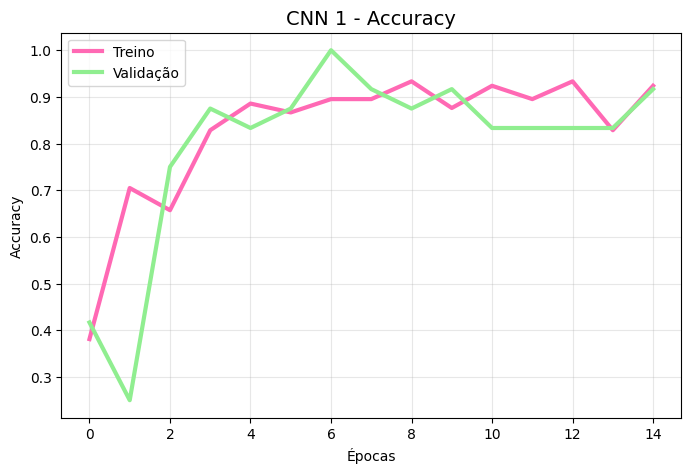

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history1.history['accuracy'],
    color='#FF69B4',
    linewidth=3,
    label='Treino'
)

plt.plot(
    history1.history['val_accuracy'],
    color='#90EE90',
    linewidth=3,
    label='Validação'
)

plt.title('CNN 1 - Accuracy', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [92]:
# Gráfico de Loss da CNN 1

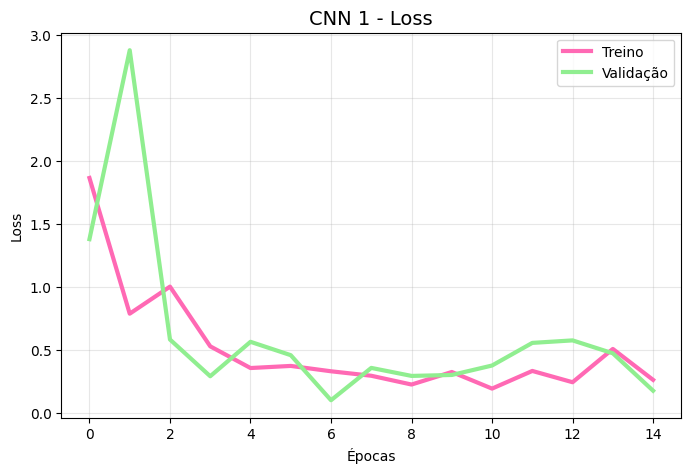

In [116]:
plt.figure(figsize=(8,5))

plt.plot(
    history1.history['loss'],
    color='#FF69B4',
    linewidth=3,
    label='Treino'
)

plt.plot(
    history1.history['val_loss'],
    color='#90EE90',
    linewidth=3,
    label='Validação'
)

plt.title('CNN 1 - Loss', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [94]:
# Gráfico de Accuracy da CNN 2

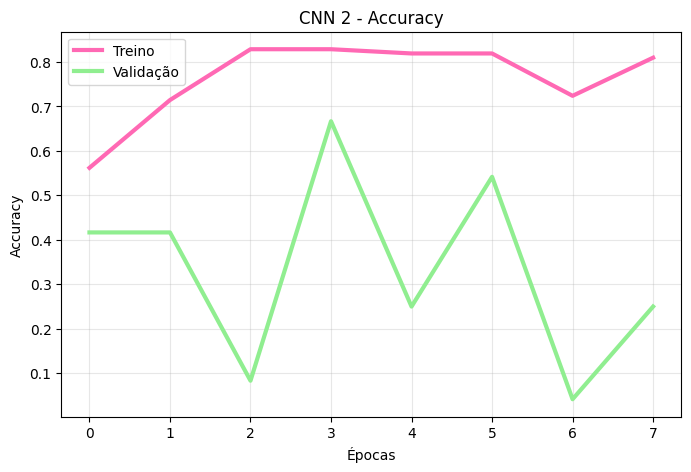

In [118]:
plt.figure(figsize=(8,5))

plt.plot(
    history2.history['accuracy'],
    color='#FF69B4',
    linewidth=3,
    label='Treino'
  )
plt.plot(
    history2.history['val_accuracy'],
    color='#90EE90',
    linewidth=3,
    label='Validação'
)

plt.title('CNN 2 - Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [96]:
# Gráfico de Loss da CNN 2

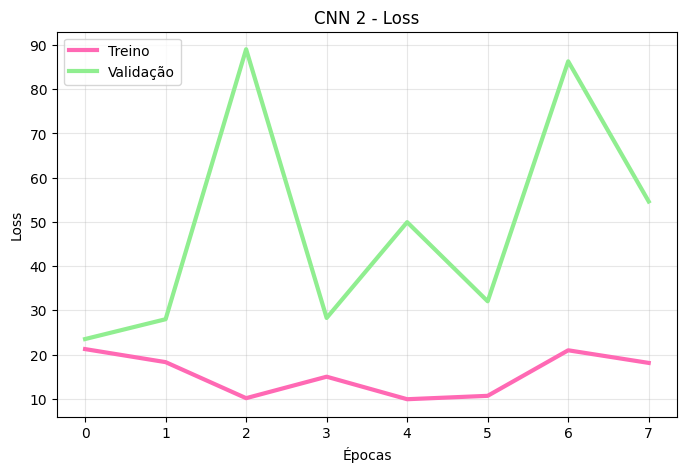

In [119]:
plt.figure(figsize=(8,5))

plt.plot(
    history2.history['loss'],
    color='#FF69B4',
    linewidth=3,
    label='Treino'
)
plt.plot(
    history2.history['val_loss'],
    color='#90EE90',
    linewidth=3,
    label='Validação'
)

plt.title('CNN 2 - Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [98]:
# Matriz de confusão da CNN 1

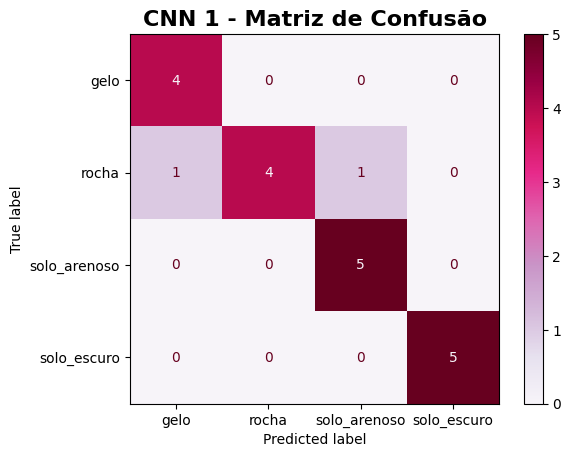

In [113]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model1.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap='PuRd',
    values_format='d'
)

plt.title(
    "CNN 1 - Matriz de Confusão",
    fontsize=16,
    fontweight='bold'
)

plt.show()

In [100]:
# Matriz de confusão da CNN 2

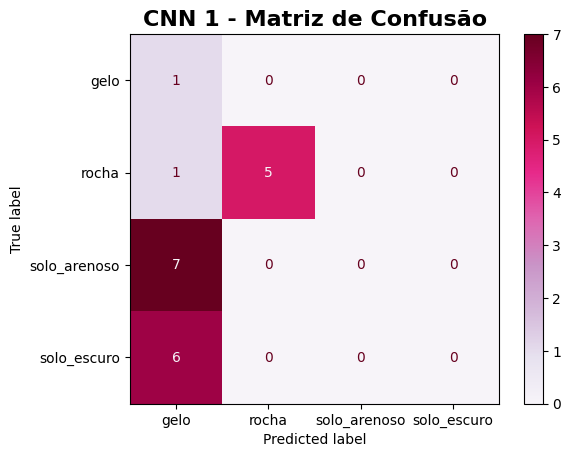

In [111]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model2.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap='PuRd',
    values_format='d'
)

plt.title(
    "CNN 1 - Matriz de Confusão",
    fontsize=16,
    fontweight='bold'
)

plt.show()

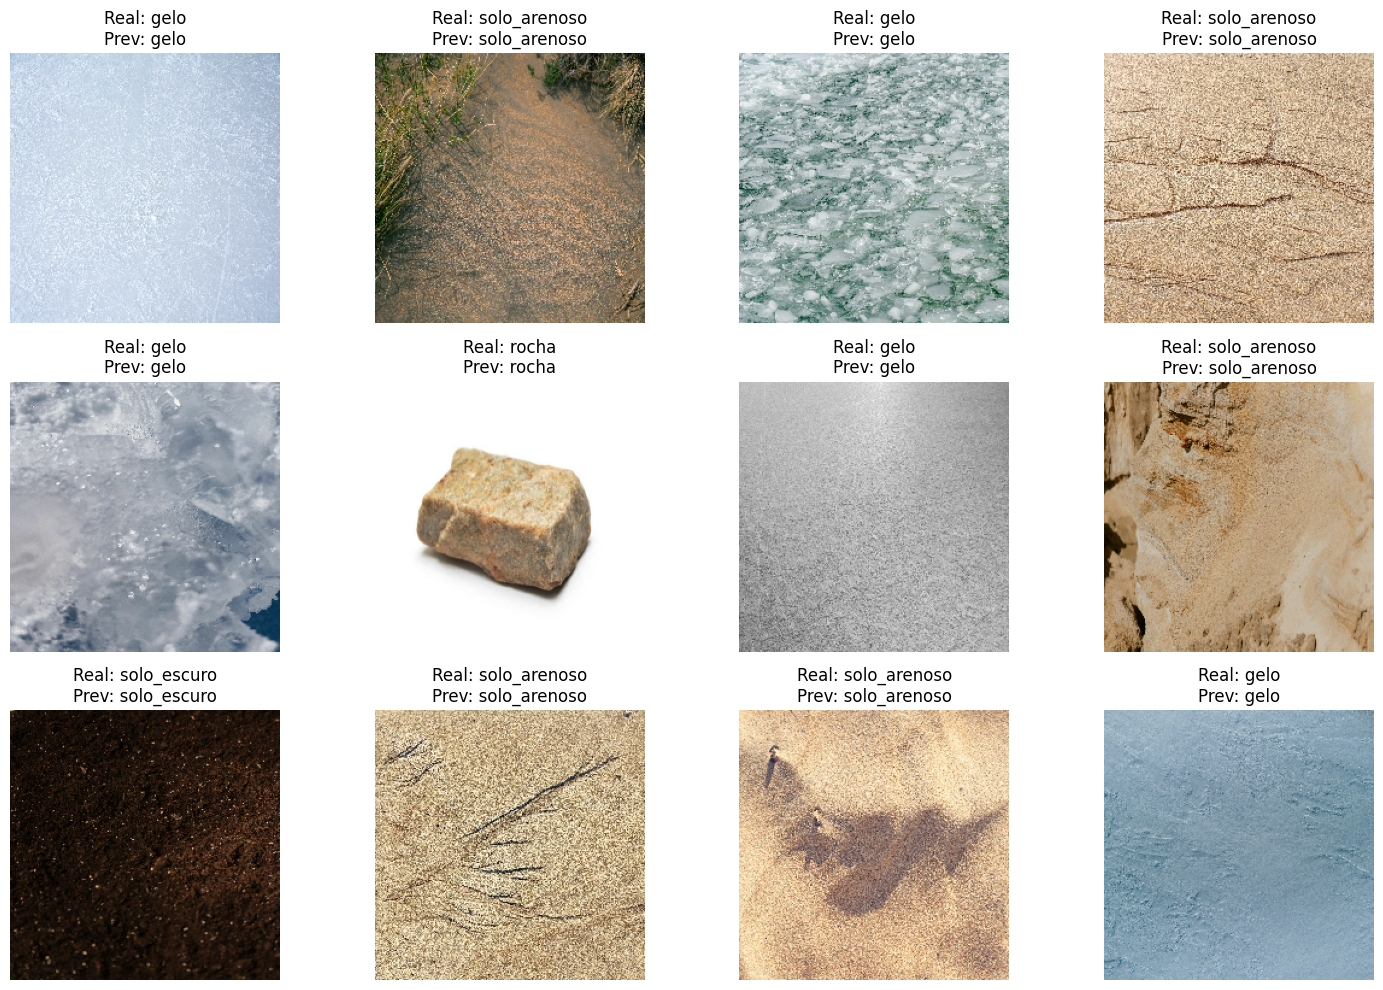

In [102]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,10))

contador = 1

for images, labels in test_ds:

    predictions = model1.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(len(images)):

        if contador > 12:
            break

        plt.subplot(3,4,contador)

        plt.imshow(images[i].numpy().astype("uint8"))

        real = class_names[labels[i]]
        prev = class_names[predicted_classes[i]]

        plt.title(
            f"Real: {real}\nPrev: {prev}"
        )

        plt.axis("off")

        contador += 1

    if contador > 12:
        break

plt.tight_layout()
plt.show()

In [103]:
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['CNN 1', 'CNN 2'],
    'Accuracy': [acc1, acc2]
})

print(resultados)

  Modelo  Accuracy
0  CNN 1      0.95
1  CNN 2      0.45


In [104]:
model1.save("astravision_cnn1.keras")

In [105]:
from google.colab import files

files.download("astravision_cnn1.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:
!pip install gradio

In [107]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "astravision_cnn1.keras"
)

In [108]:
class_names = [
    "gelo",
    "rocha",
    "solo_arenoso",
    "solo_escuro"
]

In [120]:
import numpy as np

def classificar_amostra(imagem):

    img = tf.image.resize(imagem, (224,224))
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)

    classe = class_names[np.argmax(pred)]

    confianca = np.max(pred) * 100

    return f"""
AstraVision

Classe Identificada:
{classe.upper()}

Confiança:
{confianca:.2f}%

Status:
Classificação concluída com sucesso.
"""

In [122]:
import gradio as gr

interface = gr.Interface(
    fn=classificar_amostra,

    inputs=gr.Image(),

    outputs=gr.Textbox(
        lines=10,
        label="Resultado"
    ),

    title="AstraVision",

    description="""
Sistema Inteligente de Classificação de Amostras Espaciais

Classes: Gelo; Rocha; Solo Arenoso; Solo Escuro
"""
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cd780c93d79d7ef008.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
